In [ ]:
'''
Types of Regression Model Evaluation
-------------------------------------
1. Cross Validation (Universal)
    - Mostly used for small or medium size datasets (<= 100000)
    - Model will learn train data 5 to 6 times.
    
2. Polynomial Regression
    - If our feature contains any non-linear pattern.
    - Handles non linear pattern.

3. Ridge Regression
    - Converts high weight features to 0 or close to zero
    
4. Lasso Regression
    - Removes high weight features
    
5. Elastic Net
    - Hybrid Regression -> Combination of Ridge Regression and Lasso Regression

6. Adjusting R2 Score
    - 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
    - n -> n_samples (X_test_scale.shape[0])
    - p -> population (X_train_scale.shape[1])
'''

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Linear, Ridge, Lasso, ElasticNet models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# to split feature and target data, and cross validation
from sklearn.model_selection import train_test_split, KFold, cross_val_score
# for scaling of data and polynomial regression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# Import metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import Pipeline
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv('Dataset/Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
# Adjusting R2 Score Function
def adjust_r2_score(r2, n, p):
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

In [5]:
# Separating Features and Target
features = ['X2 house age', 'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target = 'Y house price of unit area'

# Initializing feature and target to new X and Y variable
X = df[features]
Y = df[target]

# Spliting data: Training and Testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

<Axes: >

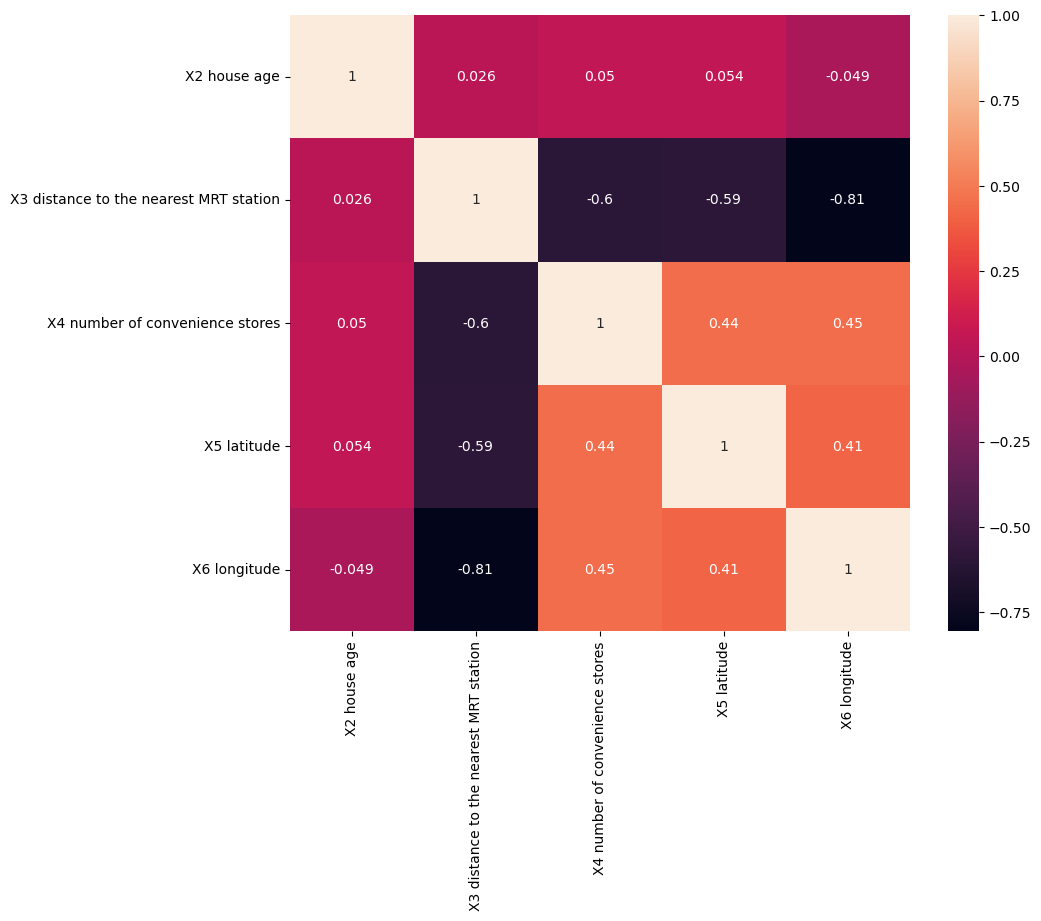

In [8]:
data = df[features]

val = data.corr()

plt.figure(figsize = (10, 8))
sns.heatmap(val, annot=True)


In [5]:
# Feature Sccaling
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [6]:
# Linear Regression Model
model = LinearRegression()
model.fit(X_train_scale, Y_train)
Y_pred = model.predict(X_test_scale)

In [7]:
# values for adjusting r2 score
n_samples = X_test_scale.shape[0]
p_data = X_train_scale.shape[1]

In [8]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
adjust_r2 = adjust_r2_score(r2, n_samples, p_data)

In [9]:
print(f'Mean Absolute Error: {mae:,.2f}')
print(f'Mean Squared Error: {mse:,.2f}')
print(f'Root Mean Squared Error: {rmse:,.2f}')
print(f'Residual Score (R2): {r2:,.2f}')
print(f'Adjusted R2 Score: {adjust_r2:,.2f}')

Mean Absolute Error: 5.35
Mean Squared Error: 54.58
Root Mean Squared Error: 7.39
Residual Score (R2): 0.67
Adjusted R2 Score: 0.65


#### Cross Validation of Data

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, scaler.fit_transform(X), Y, scoring='r2')

print(f'Cross Validation Scores: {cv_scores}')
print(f'Average Cross Validation Score: {cv_scores.mean()}')

Cross Validation Scores: [0.68463546 0.53209757 0.66649314 0.42112676 0.57912236]
Average Cross Validation Score: 0.5766950593066446


#### Polynomial Regression

In [ ]:
# If data contains non-linear pattern then use polynomial regression
poly_features = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias = False)),
    ('linear', LinearRegression())
])
# degree = 2 -> to find non linear patterns
# include_bias = False -> to stop model biasness
poly_features.fit(X_train_scale, Y_train)
poly_pred = poly_features.predict(X_test_scale)
poly_r2 = r2_score(Y_test, poly_pred)
poly_adjusted_r2 = adjust_r2_score(poly_r2, n_samples, p_data)

print(f'Polynomial Regression R2 Score: {poly_r2}')
print(f'Polynomial Adjusted R2 Score: {poly_adjusted_r2}')

Polynomial Regression R2 Score: 0.7505332250103934
Polynomial Adjusted R2 Score: 0.7343340837773021


In [ ]:
'''
alpha = 0.1, 1.0, 10, 1000

Ridge Regression standard alpha value -> 1.0 -> l1
Lasso Regression and ElasticNet Regression Standard alpha value -> 0.1 -> l2
'''

#### Ridge Regression

In [ ]:
# Convert high weight features to near Zero to match weight of low features data
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=0.1))
])
ridge_pipeline.fit(X_train_scale, Y_train)
ridge_pred = ridge_pipeline.predict(X_test_scale)
ridge_r2 = r2_score(Y_test, ridge_pred)
adjusted_ridge_r2 = adjust_r2_score(ridge_r2, n_samples, p_data)

print(f'Ridge Regression R2 Score: {ridge_r2:,.2f}')
print(f'Adjusted Ridge Regression R2 Score: {adjusted_ridge_r2:,.2f}')

Ridge Regression R2 Score: 0.67
Adjusted Ridge Regression R2 Score: 0.65


#### Lasso Regression

In [ ]:
# Removes high weight features
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])
lasso_pipeline.fit(X_train_scale, Y_train)
lasso_pred = lasso_pipeline.predict(X_test_scale)
lasso_r2 = r2_score(Y_test, lasso_pred)
adjusted_lasso_r2 = adjust_r2_score(lasso_r2, n_samples, p_data)

print(f'Lasso Regression R2 Score: {lasso_r2:,.2f}')
print(f'Adjusted Lasso Regression R2 Score: {adjusted_lasso_r2:,.2f}')

Lasso Regression R2 Score: 0.68
Adjusted Lasso Regression R2 Score: 0.66


#### ElasticNet Regression

In [ ]:
# If required high weighted features will be removed, If not required then high weight feature value will be
# minimized to near zero.
elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet(alpha=0.1, l1_ratio=0.5))
])
elastic_pipeline.fit(X_train_scale, Y_train)
elastic_pred = elastic_pipeline.predict(X_test_scale)
elastic_r2 = r2_score(Y_test, elastic_pred)
adjusted_elastic_r2 = adjust_r2_score(elastic_r2, n_samples, p_data)

print(f'ElasticNet Regression R2 Score: {elastic_r2:,.2f}')
print(f'Adjusted ElasticNet Regression R2 Score: {adjusted_elastic_r2:,.2f}')

ElasticNet Regression R2 Score: 0.68
Adjusted ElasticNet Regression R2 Score: 0.66


### Visualization

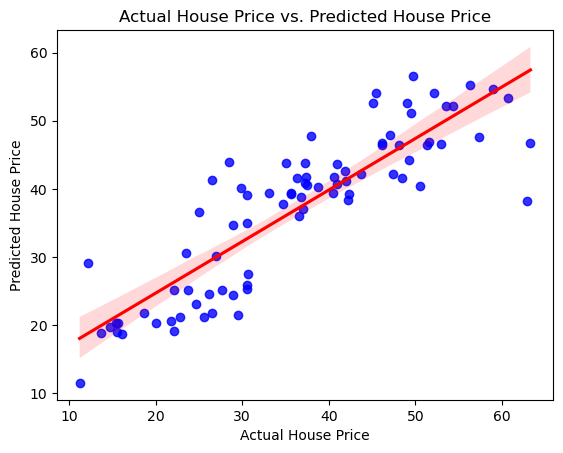

In [ ]:
sns.regplot(x=Y_test, y=poly_pred, color='blue', line_kws={'color':'red'})
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual House Price vs. Predicted House Price')
plt.show()